# Swiggy Sales Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_excel('swiggy_data.xlsx')

In [5]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [6]:
print("Total Number of Rows:",df.shape[0])

Total Number of Rows: 197430


In [7]:
print("Total Number of Columns:",df.shape[1])

Total Number of Columns: 10


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [9]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


### KPI's

In [10]:
total_sales = df['Price (INR)'].sum()
print('Total Sales (INR) : ',round(total_sales,2))

Total Sales (INR) :  53012505.77


In [11]:
average_rating = df['Rating'].mean()
print('Average Rating:',round(average_rating,2))

Average Rating: 4.34


In [12]:
Average_order_value = df['Price (INR)'].mean()
print('Average Order Value:',round(Average_order_value,2))

Average Order Value: 268.51


In [13]:
Rating_count = df['Rating Count'].count()
print("Total No of Customer Rating:",round(Rating_count,2))

Total No of Customer Rating: 197430


In [14]:
Total_Order = df.shape[0]
print('Total Number of Order Recieve:',Total_Order)

Total Number of Order Recieve: 197430


### Chart Design


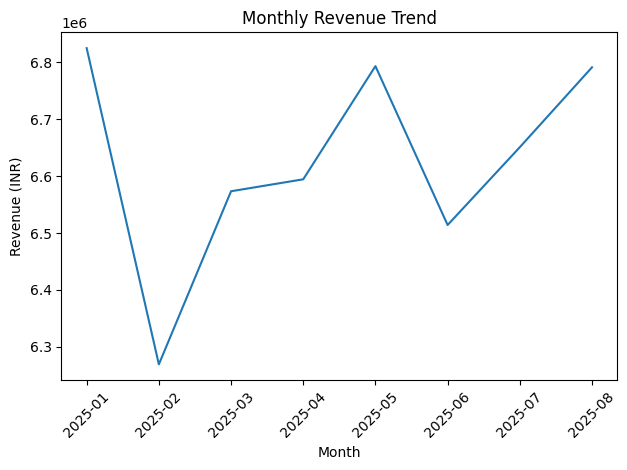

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period("M").astype(str)

monthly_revenue = df.groupby('YearMonth')['Price (INR)'].sum().reset_index()

plt.Figure()
plt.plot(monthly_revenue['YearMonth'],monthly_revenue['Price (INR)'])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

### Daily Sale Trend

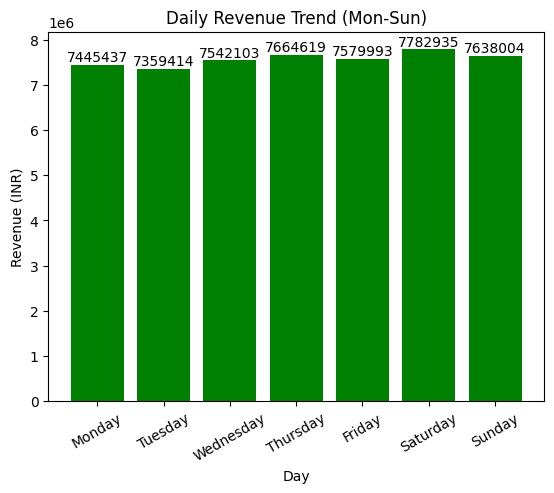

In [16]:
df['DayName'] = pd.to_datetime(df['Order Date']).dt.day_name()

day_revenue = (
                df.groupby("DayName")['Price (INR)']
               .sum()
               .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday",'Saturday','Sunday']) 
               )


plt.Figure(figsize=(10,5))
plt.bar(day_revenue.index,day_revenue.values,color='green')
plt.bar_label(plt.gca().containers[0], fmt='%.0f')  # no decimals
plt.title('Daily Revenue Trend (Mon-Sun)')
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()

### Total Sales by food type (veg / non-veg)

In [17]:
non_veg_keywords = ['chicken','egg','fish','mutton','prawn','biryani','kabab','non-veg','non veg']

df['food_category'] = np.where(
    df['Dish Name'].str.lower().str.contains("|".join(non_veg_keywords),na='False'), # | this work as OR Condition
    "Non-Veg",
    "Veg"
)



In [18]:
food_revenue =( df.groupby('food_category')['Price (INR)'].sum().reset_index() )



fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="food_category",
    hole=0.5,
    title="Revenue Contribution : Veg / Non-Veg"
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05,0]
)

fig.update_layout(
    height=500,
    margin=dict(t=60,b=40,l=40,r=40)
)

fig.show()


### Total Sales By States

In [19]:
State_Sales = df.groupby('State',as_index=False)["Price (INR)"].sum().sort_values('Price (INR)',ascending=False)

fig = px.bar(State_Sales,
             x = "Price (INR)",
             y = "State",
             orientation="h",
             title="Revenue By State"
             )
fig.update_layout(height=600, yaxis=dict(autorange="reversed"))
fig.show()


### Quarterly Performance Summary

In [20]:
df['Order Date'] = pd.to_datetime(df["Order Date"])

df['Ouarter'] = df["Order Date"].dt.to_period('Q').astype(str)

quarterly_summary = (
    df.groupby('Ouarter',as_index=False).agg(
        total_sales = ("Price (INR)","sum"),
        Avg_rating = ("Rating","mean"),
        Total_Order = ("Order Date","count")
    )
    .sort_values("Ouarter")
)

quarterly_summary['total_sales'] = quarterly_summary['total_sales'].round(0)
quarterly_summary['Avg_rating'] = quarterly_summary['Avg_rating'].round(2)

quarterly_summary



,Ouarter,total_sales,Avg_rating,Total_Order
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Top 5 city by sales

In [22]:
top_5_cities = (
    df.groupby('City')['Price (INR)']
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
) 


fig=px.bar(
    top_5_cities,
    x="Price (INR)",
    y = "City",
    orientation="h",
    title="Top 5 Cities By Sales",
    color_discrete_sequence=['red'] 
)

fig.show()

### Weekly Trend Analysis

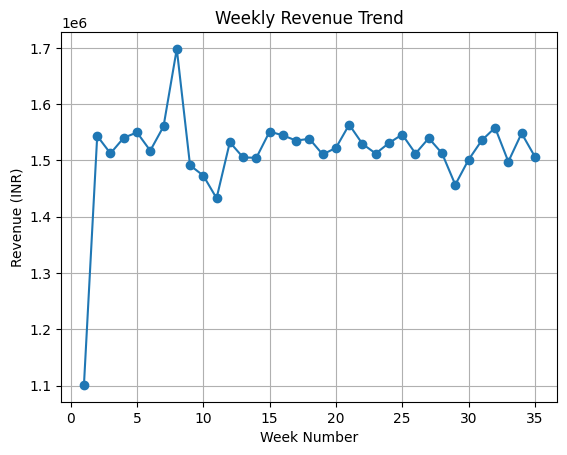

In [26]:
df['Order Date'] = df['Order Date'].dt.to_timestamp()
df['week'] = df['Order Date'].dt.isocalendar().week

Weekly_trend = (
    df.groupby('week')['Price (INR)']
    .sum()
    .reset_index()
)


plt.Figure(figsize=(10,5))
plt.plot(Weekly_trend['week'],Weekly_trend['Price (INR)'], marker='o')

plt.title('Weekly Revenue Trend')
plt.xlabel('Week Number')
plt.ylabel('Revenue (INR)')

plt.grid(True)
plt.show()
